# Robustness: 10 kHz vs 15 kHz and ±30% (Lf,Rf)


In [1]:
import sys
from pathlib import Path
PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import matplotlib.pyplot as plt

from hybrid_acdc_odlvc.config import PlantParams, ControlParams, ProfileParams
from hybrid_acdc_odlvc.profiles import default_profiles_24h
from hybrid_acdc_odlvc.sim import run_sim_24h


In [2]:
cp = ControlParams()
pr = ProfileParams(compress_24h_to_s=12.0, P_ren_max_w=18000.0)
prof = default_profiles_24h()

cases=[('10 kHz, nominal', dict(Ts=1e-4, Lf=2.5e-3, Rf=0.08)),
       ('15 kHz, nominal', dict(Ts=1/15000, Lf=2.5e-3, Rf=0.08)),
       ('10 kHz, +30% Lf,Rf', dict(Ts=1e-4, Lf=2.5e-3*1.3, Rf=0.08*1.3)),
       ('10 kHz, -30% Lf,Rf', dict(Ts=1e-4, Lf=2.5e-3*0.7, Rf=0.08*0.7))]

logs=[]
for label,p in cases:
    pp=PlantParams(Ts=p['Ts'], Lf=p['Lf'], Rf=p['Rf'])
    logs.append((label, run_sim_24h(pp, cp, pr, prof, 'odl_vc', pr.compress_24h_to_s)))


In [3]:
# ---- Plot decimation ----
dec = 50
logs_d = [(label, {k: log[k][::dec] for k in log}) for label, log in logs]


In [4]:
print("Vdc_ref =", cp.Vdc_ref)
print("Vdc_min =", cp.Vdc_min)
print("Vdc_max =", cp.Vdc_max)


Vdc_ref = 680.0
Vdc_min = 675.0
Vdc_max = 685.0


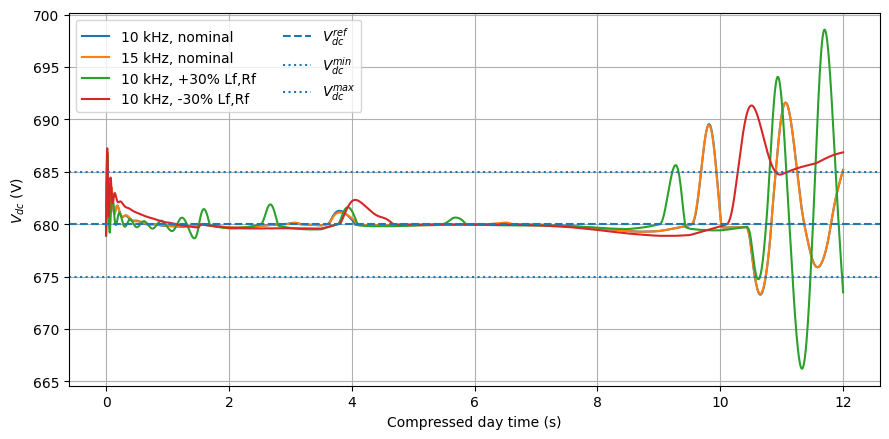

In [5]:
plt.figure(figsize=(9,4.5))
for label,log in logs_d:
    plt.plot(log['t'], log['Vdc'], label=label)

plt.axhline(cp.Vdc_ref, linestyle='--', label='$V_{dc}^{ref}$')
plt.axhline(cp.Vdc_min, linestyle=':', label='$V_{dc}^{min}$')
plt.axhline(cp.Vdc_max, linestyle=':', label='$V_{dc}^{max}$')

plt.xlabel('Compressed day time (s)')
plt.ylabel('$V_{dc}$ (V)')
plt.grid(True)
plt.legend(ncol=2)
plt.tight_layout()
plt.show()


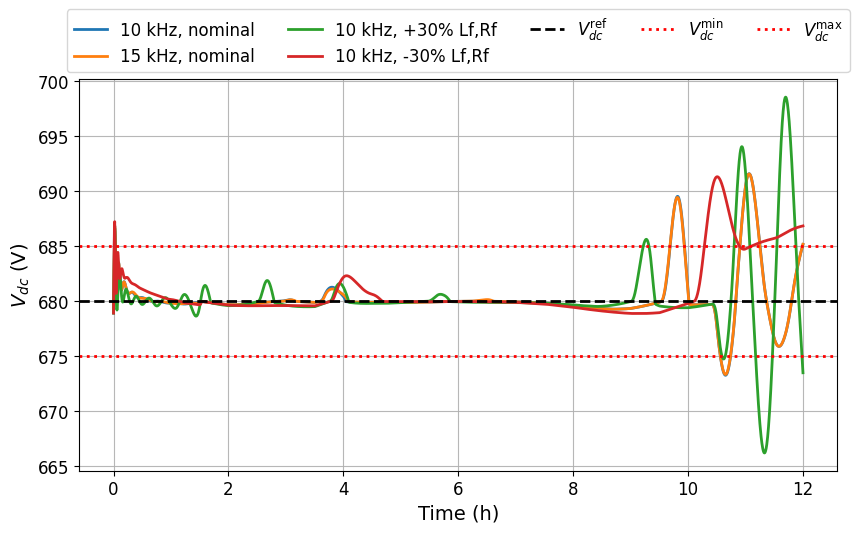

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 5.5))

# ---- Vdc trajectories ----
for label, log in logs_d:
    plt.plot(
        log['t'],
        log['Vdc'],
        linewidth=2,
        label=label
    )

# ---- Reference and limits ----
plt.axhline(cp.Vdc_ref, linestyle='--', color='black', linewidth=2,
            label=r'$V_{dc}^{\mathrm{ref}}$')
plt.axhline(cp.Vdc_min, linestyle=':', color='red', linewidth=2,
            label=r'$V_{dc}^{\min}$')
plt.axhline(cp.Vdc_max, linestyle=':', color='red', linewidth=2,
            label=r'$V_{dc}^{\max}$')

# ---- Formatting ----
plt.xlabel('Time (h)', fontsize=14)
plt.ylabel(r'$V_{dc}$ (V)', fontsize=14)

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.grid(True, which='both', linestyle='-', linewidth=0.8, alpha=0.9)

# ---- Horizontal legend ----
plt.legend(
    loc='upper center',
    bbox_to_anchor=(0.5, 1.2),
    ncol=5,              # horizontal layout
    fontsize=12,
    frameon=True
)

plt.tight_layout()

plt.savefig(
    "Fig_Vdc_Robustness_Comparison.pdf",
    format="pdf",
    bbox_inches="tight"
)

plt.show()


In [20]:
# ---- Robustness metric: Max |Vdc - Vdc_ref| ----

metrics = []

for label, log in logs:
    Vdc = np.asarray(log['Vdc'])
    t   = np.asarray(log['t'])

    # Ignore the very beginning (initial transient)
    t_ignore = 0.5 * pr.compress_24h_to_s / 24.0   # ~0.5 h equivalent
    idx = t > t_ignore

    max_dev = np.max(np.abs(Vdc[idx] - cp.Vdc_ref))
    metrics.append((label, max_dev))

# Print results (for paper/table)
print("Robustness metric: Max |Vdc - Vdc_ref|")
for label, val in metrics:
    print(f"{label:25s}: {val:6.2f} V")


Robustness metric: Max |Vdc - Vdc_ref|
10 kHz, nominal          :  11.60 V
15 kHz, nominal          :  11.58 V
10 kHz, +30% Lf,Rf       :  18.57 V
10 kHz, -30% Lf,Rf       :  11.33 V
